# 03_limpieza_datos

Proyecto ARIMA / ARIMAX
Modelación epidemiológica con variables meteorológicas.

### Obtención de datos SST (Temperatura superficial del mar)

In [ ]:
import xarray as xr
import pandas as pd
import os

# ==================== TU RUTA ====================
folder = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\SST"

files = [
    os.path.join(folder, "sst.day.anom.2021.nc"),
    os.path.join(folder, "sst.day.anom.2022.nc"),
    os.path.join(folder, "sst.day.anom.2023.nc"),
    os.path.join(folder, "sst.day.anom.2024.nc"),
    os.path.join(folder, "sst.day.anom.2025.nc"),
    os.path.join(folder, "sst.day.anom.2026.nc")
]

start_date = "2021-01-03"
end_date   = "2026-01-03"

print("Iniciando extracción de SST anomalía Niño 3.4...")

# Abrir archivos
ds = xr.open_mfdataset(files, combine='by_coords')

# Seleccionar período
ds_sel = ds.sel(time=slice(start_date, end_date))

# === REGIÓN NIÑO 3.4 CORRECTA ===
sst_region = ds_sel['anom'].sel(
    lat=slice(-5.0, 5.0),     # 
    lon=slice(190.0, 240.0)   # 
)

# Promedio diario
sst_daily = sst_region.mean(dim=['lat', 'lon'], skipna=True)

# Convertir a DataFrame
df = sst_daily.to_dataframe().reset_index()
df = df[['time', 'anom']].rename(columns={'time': 'fecha', 'anom': 'sst_anomaly_nino34'})

# Guardar como Excel
output_file = os.path.join(folder, "SST_anomaly_Nino34_diaria_2021_2026.xlsx")

df.to_excel(output_file, index=False)

print("¡Proceso terminado!")
print(f"Número de días: {len(df)}")
print(f"Valores NaN: {df['sst_anomaly_nino34'].isna().sum()}")
print("\nPrimeros 10 registros:")
print(df.head(10))
print(f"\nArchivo guardado en:\n{output_file}")

# Obtención de los datos epidemiológicos 

In [75]:
# Inicio del análisis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  


In [76]:
# Importar datos epidemiológicos 
df_epi_caucasia=pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2021-2025_CAUCASIA.xlsx")

# Importar datos meteorológicos 
df_meteo_caucasia=pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos meteorológicos\Datos_NS_2021-2025_SOI-SST.xlsx")


In [77]:
df_epi_caucasia.head(2)

,ini_sin_,semana,año,area_,localidad_,cen_pobla_,vereda_,bar_ver_,dir_res_,nmun_proce,nmun_resi
0,2021-01-21,3,2021,2,NO APLICA,CAUCASIA,NO APLICA,CAUCASIA,CR 39 E 48 C SUR 36,CAUCASIA,ENVIGADO
1,2021-02-08,6,2021,2,NO APLICA,CAUCASIA,NO APLICA,CAUCASIA,CL 29 A 42-99,CAUCASIA,BOGOTA


In [78]:
df_meteo_caucasia.head(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,QV2M,RH2M,PRECTOTCORR,WS2M,WS2M_MAX,WS2M_MIN,ALLSKY_SFC_UV_INDEX,SOI,SST_ANOMALY
0,2021,3,28.33,35.09,23.84,18.15,78.13,5.83,0.13,0.32,0.07,2.48,23.42,-1.038442
1,2021,4,28.71,35.05,23.69,16.29,69.26,0.77,0.14,0.30,0.07,2.47,25.40,-1.071886


In [79]:
df_meteo_caucasia.columns

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'QV2M', 'RH2M',
       'PRECTOTCORR', 'WS2M', 'WS2M_MAX', 'WS2M_MIN', 'ALLSKY_SFC_UV_INDEX',
       'SOI', 'SST_ANOMALY'],
      dtype='object')

In [80]:
df_epi_caucasia.columns 

Index(['ini_sin_', 'semana', 'año', 'area_', 'localidad_', 'cen_pobla_',
       'vereda_', 'bar_ver_', 'dir_res_', 'nmun_proce', 'nmun_resi'],
      dtype='object')

# Remuestreo de los datos Epidemiológicos a frecuencia semanal 

In [81]:
# remuestreo epidemiológico 2024 y 2025. 2021 al 2024 con 52 semanas, 2025 con 53 semanas
# ---------------------------
# 1. AGRUPAR CASOS POR SEMANA REAL
# ---------------------------
df_epi = df_epi_caucasia.copy()

df_semanal = df_epi.groupby(['año', 'semana']).size().reset_index(name='num_casos')


# ---------------------------
# 2. ESTRUCTURA 2021–2024 (52 semanas)
# ---------------------------
estructura_1 = pd.MultiIndex.from_product(
    [range(2021, 2025), range(1, 53)],
    names=['año', 'semana']
).to_frame(index=False)

df_1_epi = pd.merge(estructura_1, df_semanal, on=['año', 'semana'], how='left')
df_1_epi['num_casos'] = df_1_epi['num_casos'].fillna(0).astype(int)


# ---------------------------
# 3. ESTRUCTURA 2025 (53 semanas)
# ---------------------------
estructura_2 = pd.DataFrame({
    'año': [2025]*53,
    'semana': range(1, 54)
})

df_2_epi = pd.merge(estructura_2, df_semanal, on=['año', 'semana'], how='left')
df_2_epi['num_casos'] = df_2_epi['num_casos'].fillna(0).astype(int)


# ---------------------------
# 4. FECHAS CORRECTAS (CLAVE)
# ---------------------------
inicios = {
    2021: '2021-01-03',
    2022: '2022-01-02',
    2023: '2023-01-01',
    2024: '2023-12-31',  # ← corrige el error de 25 vs 22 dic
    2025: '2024-12-29'
}

def asignar_fecha(row):
    inicio = pd.Timestamp(inicios[row['año']])
    return inicio + pd.to_timedelta((row['semana'] - 1) * 7, unit='D')


# Aplicar
df_1_epi['fecha'] = df_1_epi.apply(asignar_fecha, axis=1)
df_2_epi['fecha'] = df_2_epi.apply(asignar_fecha, axis=1)


# ---------------------------
# 5. UNIR TODO
# ---------------------------
df_final_epi = pd.concat([df_1_epi, df_2_epi])

df_final_epi = df_final_epi.sort_values('fecha').set_index('fecha')
df_final_epi = df_final_epi.rename(columns={'semana': 'semana_epi'})

In [82]:
df_1_epi

,año,semana,num_casos,fecha
0,2021,1,0,2021-01-03
1,2021,2,0,2021-01-10
2,2021,3,1,2021-01-17
3,2021,4,0,2021-01-24
4,2021,5,0,2021-01-31
...,...,...,...,...
203,2024,48,68,2024-11-24
204,2024,49,92,2024-12-01
205,2024,50,85,2024-12-08
206,2024,51,74,2024-12-15


In [83]:
df_2_epi.tail(3)

,año,semana,num_casos,fecha
50,2025,51,7,2025-12-14
51,2025,52,5,2025-12-21
52,2025,53,9,2025-12-28


### Meteorológicos

In [84]:
# Renombrar columnas del dataframe nasa
df_meteo_caucasia.rename(columns={
    'YEAR': 'año',
    'DOY': 'dia',
    'T2M': 'temp',
    'T2M_MAX': 'temp_max',
    'T2M_MIN': 'temp_min',
    'QV2M': 'hum_esp',
    'RH2M': 'hum_rel',
    'PRECTOTCORR': 'prec',
    'WS2M': 'vel_vi',
    'WS2M_MAX': 'vel_vi_max',
    'WS2M_MIN': 'vel_vi_min',
    'ALLSKY_SFC_UV_INDEX': 'uv',
    'SOI': 'soi',
    'SST_ANOMALY': 'sst_anomaly'
}, inplace=True)
df_meteo_caucasia.head(3)

,año,dia,temp,temp_max,temp_min,hum_esp,hum_rel,prec,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly
0,2021,3,28.33,35.09,23.84,18.15,78.13,5.83,0.13,0.32,0.07,2.48,23.42,-1.038442
1,2021,4,28.71,35.05,23.69,16.29,69.26,0.77,0.14,0.30,0.07,2.47,25.40,-1.071886
2,2021,5,27.85,34.96,22.71,15.36,69.34,0.80,0.16,0.34,0.03,2.30,20.07,-1.103086


In [85]:
df_meteo_caucasia.columns

Index(['año', 'dia', 'temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
       'prec', 'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv', 'soi',
       'sst_anomaly'],
      dtype='object')

In [86]:
df_meteo = df_meteo_caucasia.copy()

# Crear fecha real
df_meteo['fecha'] = pd.to_datetime(df_meteo['año'].astype(str) + '-' + df_meteo['dia'].astype(str), format='%Y-%j')

In [87]:
df_meteo['dias_lluvia'] = (df_meteo['prec'] >= 1).astype(int)

In [88]:
inicios = {
    2021: pd.Timestamp('2021-01-03'),
    2022: pd.Timestamp('2022-01-02'),
    2023: pd.Timestamp('2023-01-01'),
    2024: pd.Timestamp('2023-12-31'),
    2025: pd.Timestamp('2024-12-29')
}

def asignar_semana(row):
    año = row['fecha'].year
    
    # Ajuste especial para fechas que pertenecen a semana epi del siguiente año
    if row['fecha'] >= inicios[2025]:
        año = 2025
    elif row['fecha'] >= inicios[2024]:
        año = 2024
    elif row['fecha'] >= inicios[2023]:
        año = 2023
    elif row['fecha'] >= inicios[2022]:
        año = 2022
    else:
        año = 2021

    semana = ((row['fecha'] - inicios[año]).days // 7) + 1
    return pd.Series([año, semana])

df_meteo[['año_epi', 'semana']] = df_meteo.apply(asignar_semana, axis=1)

In [89]:
df_semanal = df_meteo.groupby(['año_epi', 'semana']).agg({
    'temp': 'mean',
    'temp_max': 'mean',
    'temp_min': 'mean',
    'hum_esp': 'mean',
    'hum_rel': 'mean',
    'prec': 'mean',
    'dias_lluvia': 'sum',
    'vel_vi': 'mean',
    'vel_vi_max': 'mean',
    'vel_vi_min': 'mean',
    'uv': 'mean',
    'prec': 'sum',
    'soi': 'mean',
    'sst_anomaly': 'mean'
}).reset_index()

df_semanal = df_semanal.rename(columns={'año_epi': 'año'})

In [90]:
estructura_1 = pd.MultiIndex.from_product(
    [range(2021, 2025), range(1, 53)],
    names=['año', 'semana']
).to_frame(index=False)

df_1_meteo = pd.merge(estructura_1, df_semanal, on=['año', 'semana'], how='left')

In [91]:
estructura_2 = pd.DataFrame({
    'año': [2025]*53,
    'semana': range(1, 54)
})

df_2_meteo = pd.merge(estructura_2, df_semanal, on=['año', 'semana'], how='left')

In [92]:
def asignar_fecha(row):
    inicio = inicios[row['año']]
    return inicio + pd.to_timedelta((row['semana'] - 1) * 7, unit='D')

df_1_meteo['fecha'] = df_1_meteo.apply(asignar_fecha, axis=1)
df_2_meteo['fecha'] = df_2_meteo.apply(asignar_fecha, axis=1)

In [93]:
df_final_meteo = pd.concat([df_1_meteo, df_2_meteo])
df_final_meteo = df_final_meteo.sort_values('fecha').set_index('fecha')

In [94]:
df_1_meteo.tail(3)

,año,semana,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly,fecha
205,2024,50,26.778571,30.527143,23.577143,19.062857,86.507143,5.85,1,0.195714,0.518571,0.021429,1.921429,6.71,-0.382062,2024-12-08
206,2024,51,26.618571,29.824286,24.062857,19.502857,89.172857,11.85,3,0.161429,0.472857,0.021429,1.652857,14.62,-0.718384,2024-12-15
207,2024,52,26.024286,29.068571,23.940000,19.175714,90.857143,26.27,7,0.154286,0.418571,0.047143,1.724286,4.70,-0.905041,2024-12-22


In [95]:
df_2_meteo.tail(3)

,año,semana,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly,fecha
50,2025,51,26.038571,29.442857,23.658571,18.982857,89.951429,30.71,6,0.160000,0.394286,0.034286,2.067143,1.335714,-0.602770,2025-12-14
51,2025,52,25.997143,30.090000,23.008571,17.992857,85.818571,2.49,1,0.185714,0.451429,0.018571,1.995714,7.732857,-0.644495,2025-12-21
52,2025,53,26.078571,29.490000,23.778571,19.051429,90.030000,14.34,3,0.135714,0.320000,0.025714,1.842500,6.411429,-0.618948,2025-12-28


# Unir las bases de datos epidemiológicas con la base de datos meteorológica de acuerdo al criterop año semana epidemiológica 


In [96]:
# Unir datos
df_final_fusionado = (
    pd.merge(
        df_final_epi.reset_index(),
        df_final_meteo.reset_index().drop(columns=['año', 'semana']),
        on='fecha',
        how='left'
    )
    .rename(columns={'num_casos': 'casos_dengue'})
)

# Quitar hora de la fecha
df_final_fusionado['fecha'] = pd.to_datetime(df_final_fusionado['fecha']).dt.date

# Reordenar columnas
columnas_orden = [
    'fecha',
    'año',
    'semana_epi',
    'casos_dengue',
    'temp', 'temp_max', 'temp_min',
    'hum_esp', 'hum_rel',
    'prec', 'dias_lluvia',
    'vel_vi', 'vel_vi_max', 'vel_vi_min',
    'uv', 'soi', 'sst_anomaly'
]

df_final_fusionado_soi_sst = df_final_fusionado[columnas_orden]

# Guardar
df_final_fusionado_soi_sst.to_excel('df_final_fusionado_soi_sst.xlsx', index=False)

df_final_fusionado_soi_sst.head()

,fecha,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly
0,2021-01-03,2021,1,0,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,0.268571,0.047143,2.222857,20.067143,-1.060214
1,2021-01-10,2021,2,0,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,0.204286,0.038571,2.254286,18.207143,-1.058352
2,2021-01-17,2021,3,1,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,0.227143,0.045714,2.420000,10.847143,-0.931407
3,2021-01-24,2021,4,0,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,0.220000,0.035714,2.477143,15.430000,-0.837360
4,2021-01-31,2021,5,0,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,0.225714,0.030000,2.290000,9.348571,-0.897892


# Distribución de los datos

In [97]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_final_fusionado_soi_sst.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
año,0.887037,5.048390e-13,False
semana_epi,0.954090,2.453246e-07,False
casos_dengue,0.846929,2.296283e-15,False
temp,0.917537,8.004622e-11,False
temp_max,0.883120,2.825387e-13,False
temp_min,0.980537,1.226305e-03,False
hum_esp,0.948490,5.846115e-08,False
hum_rel,0.830594,3.401543e-16,False
prec,0.890732,8.840685e-13,False
dias_lluvia,0.880142,1.833430e-13,False


# Correlaciones

In [115]:
import seaborn as sns

In [116]:
df_numerico = df_final_fusionado_soi_sst.select_dtypes(include=['float64', 'int64']).drop(columns=['año'])

In [125]:
# Seleccionar solo variables numéricas (sin fecha)
df_numerico = df_final_fusionado_soi_sst.select_dtypes(include=['float64', 'int64'])

# Eliminar año y semana_epi
df_numerico = df_numerico.drop(columns=['año', 'semana_epi'])

# Calcular correlación de Spearman
corr_spearman = df_numerico.corr(method='spearman')

# Mostrar
print("Matriz de correlación de Spearman:\n")
corr_spearman

Matriz de correlación de Spearman:



,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly
casos_dengue,1.000000,-0.287808,-0.339649,-0.045969,0.564121,0.464611,0.317190,0.348841,0.330607,0.391496,-0.195037,-0.213869,-0.196389,0.397949
temp,-0.287808,1.000000,0.944800,0.709059,-0.427284,-0.829631,-0.551201,-0.610368,-0.638927,-0.637812,0.259869,0.204596,-0.175223,0.248510
temp_max,-0.339649,0.944800,1.000000,0.497955,-0.602954,-0.933592,-0.641259,-0.689705,-0.654940,-0.641925,0.257114,0.098269,-0.070627,0.074912
temp_min,-0.045969,0.709059,0.497955,1.000000,0.158813,-0.329626,-0.175032,-0.235975,-0.327682,-0.358993,0.143343,0.348099,-0.338554,0.579851
hum_esp,0.564121,-0.427284,-0.602954,0.158813,1.000000,0.771243,0.589707,0.578096,0.539590,0.580773,-0.339795,0.110665,-0.232603,0.391475
hum_rel,0.464611,-0.829631,-0.933592,-0.329626,0.771243,1.000000,0.706673,0.741996,0.628382,0.631601,-0.308944,-0.041117,-0.002524,0.067323
prec,0.317190,-0.551201,-0.641259,-0.175032,0.589707,0.706673,1.000000,0.810971,0.355247,0.315081,-0.056525,0.089984,0.005441,0.029925
dias_lluvia,0.348841,-0.610368,-0.689705,-0.235975,0.578096,0.741996,0.810971,1.000000,0.389812,0.349784,-0.059777,0.080073,-0.007930,0.022511
vel_vi,0.330607,-0.638927,-0.654940,-0.327682,0.539590,0.628382,0.355247,0.389812,1.000000,0.896761,-0.279046,-0.026988,-0.032841,0.029842
vel_vi_max,0.391496,-0.637812,-0.641925,-0.358993,0.580773,0.631601,0.315081,0.349784,0.896761,1.000000,-0.488433,-0.066768,-0.011150,-0.004656


In [126]:
# Mostrar correlación de cada variable con casos de dengue
print("\nCorrelación de Spearman con casos de dengue:\n")
corr_spearman['casos_dengue'].sort_values(ascending=False)


Correlación de Spearman con casos de dengue:



casos_dengue    1.000000
hum_esp         0.564121
hum_rel         0.464611
sst_anomaly     0.397949
vel_vi_max      0.391496
dias_lluvia     0.348841
vel_vi          0.330607
prec            0.317190
temp_min       -0.045969
vel_vi_min     -0.195037
soi            -0.196389
uv             -0.213869
temp           -0.287808
temp_max       -0.339649
Name: casos_dengue, dtype: float64

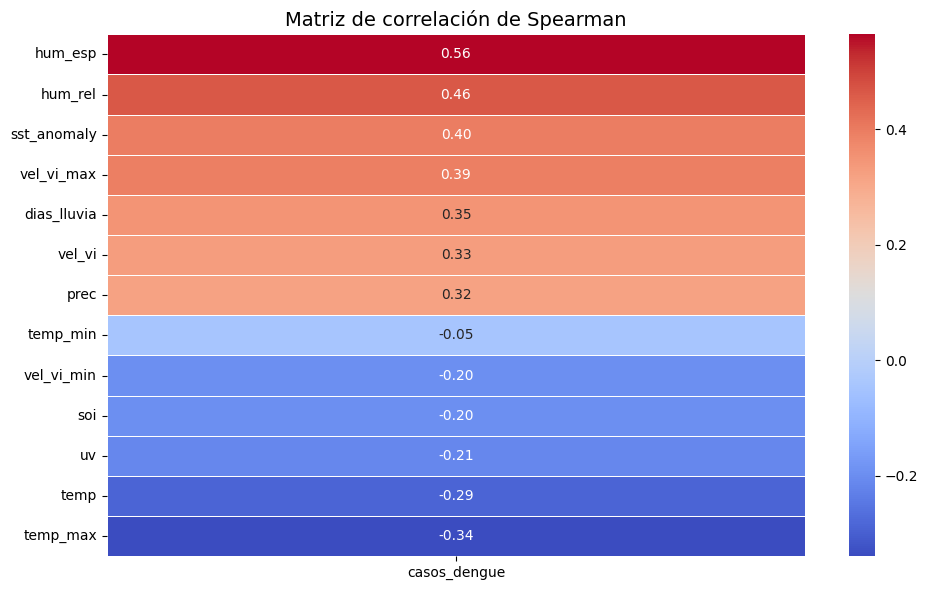

In [133]:
# Crear el mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman[['casos_dengue']].sort_values(by='casos_dengue', ascending=False)[1:], 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Matriz de correlación de Spearman', fontsize=14)
plt.tight_layout()
# guardar figura
plt.savefig('correlacion_spearman_casos_dengue.png', dpi=300)
plt.show()

In [120]:
df_2023_2026 = pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_2023-2025.xlsx")
df_2023_2026.head()

,fecha,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly
0,2023-01-01,2023,1,18,25.771429,29.727143,22.670000,17.810000,86.295714,26.57,5,0.165714,0.512857,0.020000,1.712857,21.737143,-0.802965
1,2023-01-08,2023,2,16,25.315714,28.358571,23.062857,18.154286,89.987143,30.90,6,0.152857,0.452857,0.031429,1.741429,2.540000,-0.746127
2,2023-01-15,2023,3,24,25.912857,30.352857,22.452857,17.371429,83.830000,6.22,2,0.161429,0.494286,0.018571,1.907143,11.107143,-0.738164
3,2023-01-22,2023,4,21,26.711429,31.228571,22.747143,17.225714,79.414286,0.04,0,0.171429,0.531429,0.021429,1.904286,10.430000,-0.730647
4,2023-01-29,2023,5,27,26.652857,32.178571,21.917143,16.044286,74.995714,0.00,0,0.162857,0.520000,0.021429,2.132857,13.572857,-0.618634


In [121]:
df_new = df_2023_2026.select_dtypes(include=['float64', 'int64']).drop(columns=['año'])

In [129]:
# Seleccionar solo variables numéricas (sin fecha)
df_new = df_2023_2026.select_dtypes(include=['float64', 'int64'])

# Eliminar año y semana_epi
df_new = df_new.drop(columns=['año', 'semana_epi'])

# Calcular correlación de Spearman
corr_spearman2 = df_new.corr(method='spearman')

# Mostrar
print("Matriz de correlación de Spearman:\n")
corr_spearman2

Matriz de correlación de Spearman:



,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst_anomaly
casos_dengue,1.000000,-0.114463,-0.086939,-0.093123,0.085486,0.179936,0.148786,0.212954,-0.075149,-0.051155,-0.028231,-0.054707,0.219016,-0.237688
temp,-0.114463,1.000000,0.901160,0.692363,-0.074953,-0.722198,-0.408926,-0.511516,-0.415700,-0.417601,0.115693,0.099054,-0.207515,0.502465
temp_max,-0.086939,0.901160,1.000000,0.400615,-0.367011,-0.901869,-0.549949,-0.632394,-0.439846,-0.410924,0.106817,-0.087203,-0.059753,0.259774
temp_min,-0.093123,0.692363,0.400615,1.000000,0.459630,-0.166099,-0.037150,-0.120590,-0.148787,-0.228730,0.096985,0.357211,-0.362951,0.714856
hum_esp,0.085486,-0.074953,-0.367011,0.459630,1.000000,0.611005,0.435252,0.403912,0.329802,0.343611,-0.223479,0.450194,-0.226444,0.284240
hum_rel,0.179936,-0.722198,-0.901869,-0.166099,0.611005,1.000000,0.640785,0.677084,0.392247,0.349377,-0.165195,0.198910,0.008059,-0.119776
prec,0.148786,-0.408926,-0.549949,-0.037150,0.435252,0.640785,1.000000,0.743944,0.113915,0.037364,0.061094,0.211785,-0.030331,-0.087129
dias_lluvia,0.212954,-0.511516,-0.632394,-0.120590,0.403912,0.677084,0.743944,1.000000,0.126271,0.060095,0.102039,0.191760,-0.102110,-0.079828
vel_vi,-0.075149,-0.415700,-0.439846,-0.148787,0.329802,0.392247,0.113915,0.126271,1.000000,0.842809,-0.185302,0.205988,-0.045374,-0.105667
vel_vi_max,-0.051155,-0.417601,-0.410924,-0.228730,0.343611,0.349377,0.037364,0.060095,0.842809,1.000000,-0.457683,0.190406,0.024679,-0.247347


In [130]:
# Mostrar correlación de cada variable con casos de dengue
print("\nCorrelación de Spearman con casos de dengue:\n")
corr_spearman2['casos_dengue'].sort_values(ascending=False)


Correlación de Spearman con casos de dengue:



casos_dengue    1.000000
soi             0.219016
dias_lluvia     0.212954
hum_rel         0.179936
prec            0.148786
hum_esp         0.085486
vel_vi_min     -0.028231
vel_vi_max     -0.051155
uv             -0.054707
vel_vi         -0.075149
temp_max       -0.086939
temp_min       -0.093123
temp           -0.114463
sst_anomaly    -0.237688
Name: casos_dengue, dtype: float64

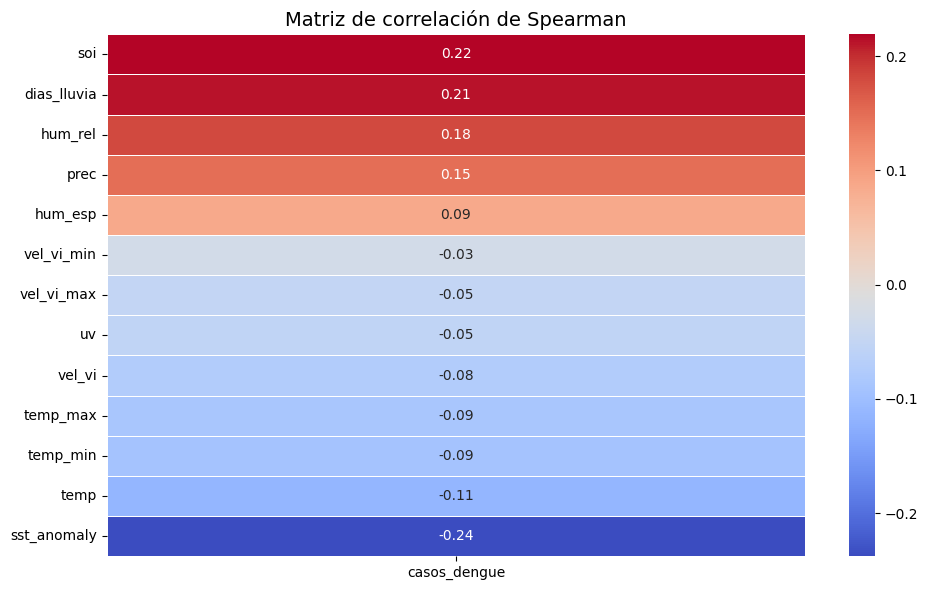

In [131]:
# Crear el mapa de calor
plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman2[['casos_dengue']].sort_values(by='casos_dengue', ascending=False)[1:], 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title('Matriz de correlación de Spearman', fontsize=14)
plt.tight_layout()
plt.show()